# Understanding the SMC's DM profile evolution in response to LMC's tides

Using the semi-analytic model of Du+2024 PRD 110, 023019 (2024)

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import plots_init as pi
from matplotlib import cm
from matplotlib.colors import Normalize

## Required function definitions

In [2]:
def delta_v_cored(delta_m):
    dv = (2**0.83)*(delta_m**0.42)/((1 + delta_m)**0.83)
    return dv

def delta_v_cusped(delta_m):
    dv = (2**0.34)*(delta_m**0.17)/((1 + delta_m)**0.34)
    return dv

def delta_r_cored(delta_m):
    dr = (2**(-0.37))*(delta_m**0.20)/((1 + delta_m)**(-0.37))
    return dr

def delta_r_cusped(delta_m):
    dr = (2**1.21)*(delta_m**0.68)/((1 + delta_m)**(1.21))
    return dr

## Plotting

In [44]:
delta_m_array = np.linspace(0.01, 0.3, 291)
dv_cored_array = delta_v_cored(delta_m_array)
dv_cusped_array = delta_v_cusped(delta_m_array)
dr_cored_array = delta_r_cored(delta_m_array)
dr_cusped_array = delta_r_cusped(delta_m_array)

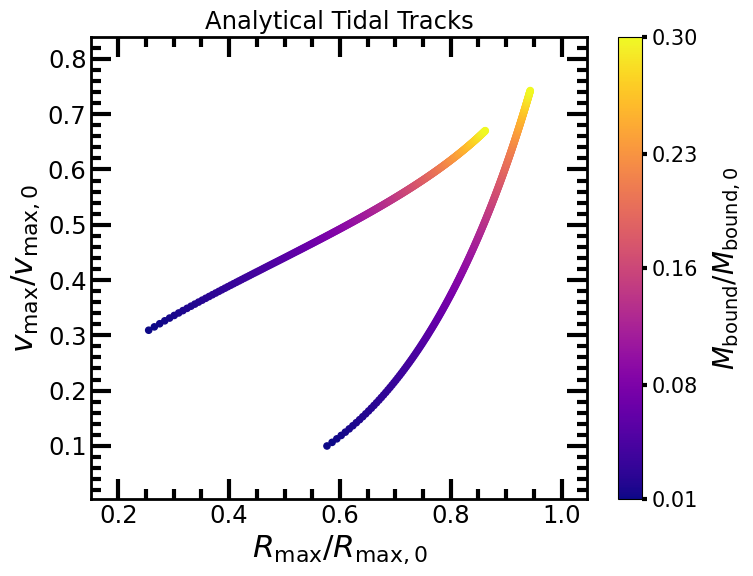

In [68]:
fig = plt.figure(figsize=(8, 6))
ax0 = fig.add_subplot(1, 1, 1)

# Create normalization object for delta_m_array values
norm = Normalize(vmin=delta_m_array.min(), vmax=delta_m_array.max())

# Plot as scatter with connecting lines
scatter_cored = ax0.scatter(dv_cored_array, dr_cored_array, c=delta_m_array, cmap='plasma', 
                            norm=norm, label="Cored Profile", s=20, zorder=3)
ax0.plot(dv_cored_array, dr_cored_array, alpha=0.3, color='gray', zorder=1)

scatter_cusped = ax0.scatter(dv_cusped_array, dr_cusped_array, c=delta_m_array, cmap='plasma', 
                             norm=norm, label="Cusped Profile", s=20, zorder=3)
ax0.plot(dv_cusped_array, dr_cusped_array, alpha=0.3, color='gray', zorder=1)

ax0.set_xlabel(r"$R_{\rm max}/R_{\rm max, 0}$")
ax0.set_ylabel(r"$v_{\rm max}/v_{\rm max, 0}$")

# Add colorbar with custom ticks matching delta_m_array values
cbar = fig.colorbar(scatter_cored, ax=ax0)
cbar.set_label(r'$M_{\rm bound}/M_{\rm bound, 0}$', labelpad = 10, size = 20)
# Set colorbar ticks to specific delta_m values
tick_indices = np.linspace(0, len(delta_m_array)-1, 5, dtype=int)
cbar.set_ticks(delta_m_array[tick_indices])
cbar.set_ticklabels([f'{val:.2f}' for val in np.round(delta_m_array[tick_indices], 2)])
cbar.ax.tick_params(labelsize = 15, width = 3)

ax0.set_title("Analytical Tidal Tracks", fontsize = 17.5)

pi.aesthetic(ax0)
plt.show()